# Agglomerative (Hierarchical) Clustering

## Table of Contents

### 1. What is Agglomerative Clustering?

### 2. Agglomerative Clustering in Scikit-Learn

### 3. Evaluation of Clustering

### 4. Important Considerations for Agglomerative Clustering

## 1. What is Agglomerative Clustering?

A hierarchical clustering method that builds a tree (dendrogram) of clusters.

“Agglomerative” means bottom-up:

- Start with each point as its own cluster

- Iteratively merge the two closest clusters

- Repeat until all points are merged into one cluster or a desired number of clusters is reached

Result: a dendrogram (tree diagram showing cluster merges)

Goal: Understand **hierarchical relationships** between data points.

**Unlike K-Means, it does not require random initialization, so results are deterministic given the same parameters**


## 2. Agglomerative Clustering in Scikit-Learn

The name of the class for Agglomerative Clustering in Scikit-Learn
  **sklearn.cluster.AgglomerativeClustering**


## **AgglomerativeClustering Parameters Explained (scikit-learn)**

### **Most Important Parameters**

### `1. n_clusters`
-  The number of clusters to form. Determines how many groups the algorithm will merge the points into.  
- default=2
- If you also set `distance_threshold`, this parameter is ignored because merging is stopped based on distance rather than cluster count.  

### `2.metric`

Distance metric used to calculate similarity between points. Determines which points are “close” to each other.

**Common Options:**  
  - `euclidean` (default) → straight-line distance; most common for numeric features.  
  - `manhattan` → sum of absolute differences; robust to outliers.  
  - `cosine` → measures angle between vectors; useful for text embeddings   

### `3. linkage`

Determines how the distance between **clusters** is computed during merging  

**Options**  

  - `ward` (default) → merges clusters that **minimize the variance** of combined cluster; produces compact, round clusters. Only works with Euclidean distance

  - `complete` → distance = **maximum distance** between any two points across clusters. Produces **tight, well-separated clusters**

  - `average` → distance = **average of all pairwise distances** between points in the two clusters. Balanced behavior between single and complete linkage

Different linkages affect **cluster shape, size and sensitivity to noise**  




**Important rules and constraints:**
- If `linkage="ward"`, **only `"euclidean"` is allowed**  
  (because Ward’s method relies on variance minimization).

Choice of metric affects which points are considered “close” and thus which clusters are merged first  


### **Occasionally Used Parameters**

### `distance_threshold`

Stops merging clusters when the distance between clusters exceeds this threshold.

**Options:** float (default=None)  

- Useful when you want a **hierarchy** and do not know the number of clusters in advance

- Example: `distance_threshold=5` → any clusters separated by more than 5 units will **not merge**, creating more clusters automatically

- If set, `n_clusters` is ignored  


### `compute_full_tree`

Determines whether the full clustering tree is computed. Needed for dendrogram plotting.  

**Options**  (default=auto)
  - `auto` → computes full tree only when needed (e.g., small datasets or dendrogram)
  - `True` → always compute the full tree; useful for plotting dendrograms  
  - `False` → skips computing full tree to save memory and computation for large datasets

### Apply Agglomerative Clustering to a simple Dataset

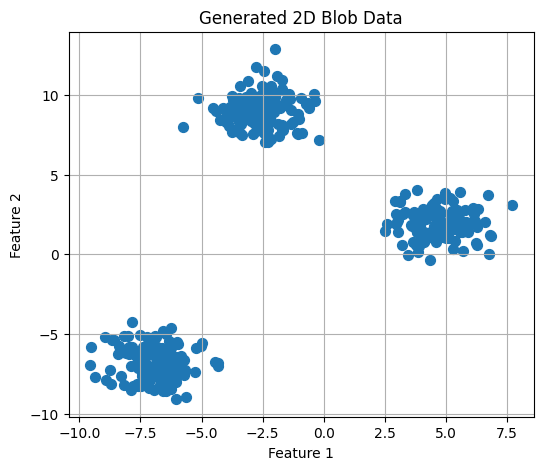

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import pandas as pd
from sklearn.metrics import silhouette_score

# Generate 400 points in 2D, 3 clusters
X, y = make_blobs(n_samples=400, n_features=2, centers=3, random_state=42)

# Plot the raw data
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Generated 2D Blob Data")
plt.grid(True)
plt.show()

Silhouette Score: 0.8458787585795497


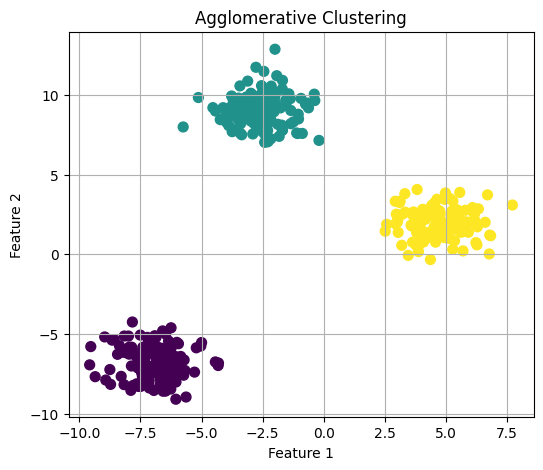

In [ ]:
# Create the model
agg = AgglomerativeClustering(
    n_clusters=3,       # we know 3 clusters exist
    metric='euclidean',  # distance metric
    linkage='ward'          # linkage method
)

# Fit and predict cluster labels
labels = agg.fit_predict(X)
score = silhouette_score(X, labels)
print("Silhouette Score:", score)
# Plot clustered data
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Agglomerative Clustering")
plt.grid(True)
plt.show()

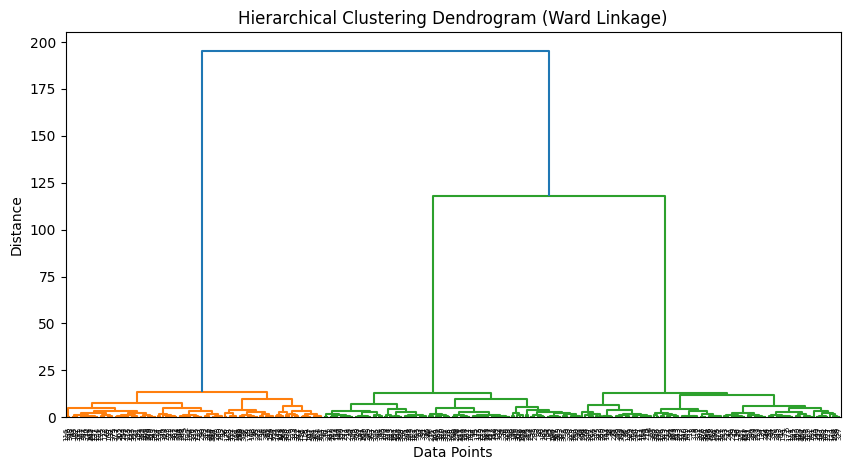

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

Z = linkage(X, method='ward', metric='euclidean')

# Plot dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

#### How to Interpret the Dendrogram

- Each leaf → one data point

- Each merge → two clusters being combined

- The height of a merge → distance between clusters

#### Choosing the Number of Clusters

- Draw a horizontal line across the dendrogram

- Count how many vertical branches it cuts

### Rule of thumb:

Choose the cut where there is a large vertical gap
(big jump in distance before clusters merge)

## Important Considerations for Agglomerative Clustering

### When to Use Agglomerative Clustering

**- Does not require specifying K upfront:**  
Hierarchical clustering can build a full hierarchy of clusters and allows you to decide the number of clusters later by cutting the dendrogram at a chosen level.

**- Works well with small to medium datasets:**  
Because it computes distances between many pairs of points, it is more suitable when the dataset is not extremely large.

**- Useful for understanding data structure:**  
The dendrogram provides a visual explanation of how data points are grouped, making it useful for exploratory analysis.

**- Flexible cluster shapes (linkage):**  
Different linkage methods allow the algorithm to capture different types of cluster structures


### Limitations of Agglomerative Clustering

**- Computationally expensive:**  
Agglomerative clustering has higher time and memory complexity, making it impractical for very large datasets

**- Sensitive to noise and outliers:**  
Outliers can form their own clusters or distort the merging process

**- Early decisions cannot be undone:**  
Once two clusters are merged, the algorithm cannot reconsider that decision later, which may lead to suboptimal clusters

**- Results depend heavily on linkage choice:**  
Different linkage methods can produce very different clusterings, so parameter selection is critical

## Task 2A: Agglomerative Clustering

In this task, you will apply **Agglomerative Clustering** to `CC GENERAL` dataset and follow **the same methodology** used in the previous clustering lab

## **1. Exploratory Data Analysis (EDA)**

In [44]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [45]:
#Load the dataset

df = pd.read_csv("C:/Users/win10/Downloads/Lab_2/CC GENERAL.CSV")

print(df.shape)

df.head()

(8950, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [46]:
#Features types
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numerical Features:", numeric_cols)
print("Categorical Features:", categorical_cols)

Numerical Features: ['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']
Categorical Features: ['CUST_ID']


In [47]:
print("--- Numerical Features Statistics ---")
print(df[numeric_cols].describe().T[["min","max","mean","std"]].round(2).to_string())
print("\nSkewness:")
print(df[numeric_cols].skew().round(2).to_string())

--- Numerical Features Statistics ---
                                    min       max     mean      std
BALANCE                            0.00  19043.14  1564.47  2081.53
BALANCE_FREQUENCY                  0.00      1.00     0.88     0.24
PURCHASES                          0.00  49039.57  1003.20  2136.63
ONEOFF_PURCHASES                   0.00  40761.25   592.44  1659.89
INSTALLMENTS_PURCHASES             0.00  22500.00   411.07   904.34
CASH_ADVANCE                       0.00  47137.21   978.87  2097.16
PURCHASES_FREQUENCY                0.00      1.00     0.49     0.40
ONEOFF_PURCHASES_FREQUENCY         0.00      1.00     0.20     0.30
PURCHASES_INSTALLMENTS_FREQUENCY   0.00      1.00     0.36     0.40
CASH_ADVANCE_FREQUENCY             0.00      1.50     0.14     0.20
CASH_ADVANCE_TRX                   0.00    123.00     3.25     6.82
PURCHASES_TRX                      0.00    358.00    14.71    24.86
CREDIT_LIMIT                      50.00  30000.00  4494.45  3638.82
PAYMENTS  

In [48]:
# --- Categorical counts ---
print("--- Categorical Feature Value Counts ---")
for col in categorical_cols:
    vc = df[col].value_counts(dropna=False).head(5)
    print(f"\n{col}:")
    print(vc.to_string())

--- Categorical Feature Value Counts ---

CUST_ID:
CUST_ID
C19190    1
C10001    1
C10002    1
C10003    1
C10004    1


In [49]:
#Missing values
print("--- Missing / Unknown Values ---")
missing = df.isnull().sum()
unknown = df.apply(lambda col: (col == "unknown").sum() if col.dtype == "object" else 0)
summary = pd.DataFrame({"null_count": missing, "unknown_count": unknown})
summary = summary[summary.sum(axis=1) > 0]

print(summary)

--- Missing / Unknown Values ---
                  null_count  unknown_count
CREDIT_LIMIT               1              0
MINIMUM_PAYMENTS         313              0


In [50]:
# Fill numeric missing values with median
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values with mode
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Verify no missing values
print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


In [51]:
#correlation between numerical values
corr_matrix = df[numeric_cols].corr()
corr_matrix

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
BALANCE,1.000000,0.322412,0.181261,0.164350,0.126469,0.496692,-0.077944,0.073166,-0.063186,0.449218,0.385152,0.154338,0.531296,0.322802,0.397920,-0.318959,0.072692
BALANCE_FREQUENCY,0.322412,1.000000,0.133674,0.104323,0.124292,0.099388,0.229715,0.202415,0.176079,0.191873,0.141555,0.189626,0.095931,0.065008,0.131181,-0.095082,0.119776
PURCHASES,0.181261,0.133674,1.000000,0.916845,0.679896,-0.051474,0.393017,0.498430,0.315567,-0.120143,-0.067175,0.689561,0.356977,0.603264,0.095789,0.180379,0.086288
ONEOFF_PURCHASES,0.164350,0.104323,0.916845,1.000000,0.330622,-0.031326,0.264937,0.524891,0.127729,-0.082628,-0.046212,0.545523,0.319735,0.567292,0.050256,0.132763,0.064150
INSTALLMENTS_PURCHASES,0.126469,0.124292,0.679896,0.330622,1.000000,-0.064244,0.442418,0.214042,0.511351,-0.132318,-0.073999,0.628108,0.256515,0.384084,0.134019,0.182569,0.086143
CASH_ADVANCE,0.496692,0.099388,-0.051474,-0.031326,-0.064244,1.000000,-0.215507,-0.086754,-0.177070,0.628522,0.656498,-0.075850,0.303997,0.453238,0.140747,-0.152935,-0.068312
PURCHASES_FREQUENCY,-0.077944,0.229715,0.393017,0.264937,0.442418,-0.215507,1.000000,0.501343,0.862934,-0.308478,-0.203478,0.568430,0.119833,0.103464,0.006154,0.305802,0.061506
ONEOFF_PURCHASES_FREQUENCY,0.073166,0.202415,0.498430,0.524891,0.214042,-0.086754,0.501343,1.000000,0.142329,-0.111716,-0.069088,0.544869,0.295059,0.243537,-0.027311,0.157531,0.082466
PURCHASES_INSTALLMENTS_FREQUENCY,-0.063186,0.176079,0.315567,0.127729,0.511351,-0.177070,0.862934,0.142329,1.000000,-0.262958,-0.169207,0.529975,0.060794,0.085551,0.032055,0.250087,0.073275
CASH_ADVANCE_FREQUENCY,0.449218,0.191873,-0.120143,-0.082628,-0.132318,0.628522,-0.308478,-0.111716,-0.262958,1.000000,0.799561,-0.131168,0.132608,0.183192,0.100616,-0.249773,-0.133372


In [52]:
#outliers
outlier_counts = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_counts[col] = len(outliers)

outlier_counts

{'BALANCE': 695,
 'BALANCE_FREQUENCY': 1493,
 'PURCHASES': 808,
 'ONEOFF_PURCHASES': 1013,
 'INSTALLMENTS_PURCHASES': 867,
 'CASH_ADVANCE': 1030,
 'PURCHASES_FREQUENCY': 0,
 'ONEOFF_PURCHASES_FREQUENCY': 782,
 'PURCHASES_INSTALLMENTS_FREQUENCY': 0,
 'CASH_ADVANCE_FREQUENCY': 525,
 'CASH_ADVANCE_TRX': 804,
 'PURCHASES_TRX': 766,
 'CREDIT_LIMIT': 248,
 'PAYMENTS': 808,
 'MINIMUM_PAYMENTS': 909,
 'PRC_FULL_PAYMENT': 1474,
 'TENURE': 1366}

## **2. Data Preparation**

In [53]:
#drop the ID column
if 'CUST_ID' in df.columns:
    df.drop(columns=['CUST_ID'], inplace=True)

In [54]:
# Encode categorical features into numeric format
df_encoded= pd.get_dummies(df, drop_first=True)

In [55]:
#scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_encoded)

In [56]:
# Check for missing values and ensure all features are numeric
print("Missing values:", pd.DataFrame(scaled_data).isnull().sum().sum())
print("All features numeric:", pd.DataFrame(scaled_data).dtypes.unique())
print("Data shape after preparation:", scaled_data.shape)

Missing values: 0
All features numeric: [dtype('float64')]
Data shape after preparation: (8950, 17)


## **3. Apply Agglomerative Clustering**

In [57]:
# Create the model
agg = AgglomerativeClustering(
    n_clusters=2,       
    metric='euclidean',  # distance metric
    linkage='ward'          # linkage method
)

# Fit and predict cluster labels
labels = agg.fit_predict(scaled_data)


## **4. Visualize the Clustering Results**

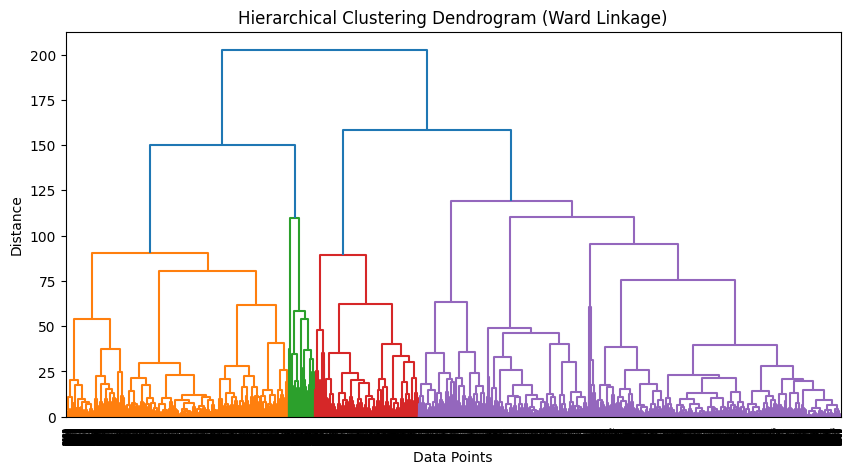

In [58]:
Z = linkage(scaled_data, method='ward', metric='euclidean')

# Plot dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

## **5. Evaluate the Clustering**

In [59]:
score = silhouette_score(scaled_data, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.19210277656035374


## **6. Explain whether the clustering quality and justify your reasoning**

The silhouette score obtained indicates weak to moderate cluster separation as it is near to 0, the point is roughly equally close to its own cluster and the nearest other cluster.
The points are on the border between clusters